# Exploratory Data Analysis (nvidia/HelpSteer2)

The [HelpSteer2](https://huggingface.co/datasets/nvidia/HelpSteer2) dataset contains prompt-response pairs annotated with 5 quality metrics:
- **helpfulness** : how useful the response is
- **correctness** : factual accuracy
- **coherence** : logical and linguistic consistency
- **complexity** : content complexity
- **verbosity** : level of verbosity

## 0. Import libraries and install dataset

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [33]:
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

In [34]:
sns.set_theme(style="whitegrid", palette="muted")
RATING_COLS = ["helpfulness", "correctness", "coherence", "complexity", "verbosity"]

dataset_train = load_dataset("nvidia/HelpSteer2", split="train")
dataset_test = load_dataset("nvidia/HelpSteer2", split="validation")

df_train = dataset_train.to_pandas()
df_test = dataset_test.to_pandas()

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

print(f"Unique prompts in training set: {df_train['prompt'].nunique()}")
print(f"Unique prompts in test set: {df_test['prompt'].nunique()}")

print(f"Missing values in training set:\n{df_train.isnull().sum()}")
print(f"Missing values in test set:\n{df_test.isnull().sum()}")

Training set shape: (20324, 7)
Test set shape: (1038, 7)
Unique prompts in training set: 10161
Unique prompts in test set: 519
Missing values in training set:
prompt         0
response       0
helpfulness    0
correctness    0
coherence      0
complexity     0
verbosity      0
dtype: int64
Missing values in test set:
prompt         0
response       0
helpfulness    0
correctness    0
coherence      0
complexity     0
verbosity      0
dtype: int64


In [35]:
df_train.head()

,prompt,response,helpfulness,correctness,coherence,complexity,verbosity
0,c#,"C# is a high-level, object-oriented programmin...",3,4,4,2,1
1,c#,"C# (pronounced ""C sharp"") is a modern, object-...",4,4,4,2,3
2,bacillus subtilus,"Bacillus subtilis is a Gram-positive, rod-shap...",4,4,4,3,3
3,bacillus subtilus,"The Bacillus subtilis is a Gram-positive, endo...",3,4,3,3,2
4,Write long detailed essay about ancient type o...,Totemism is an ancient type of religion that i...,3,3,3,2,2


## 1. Descriptive Statistics

In [36]:
print("=== Training Set ===")
display(df_train[RATING_COLS].describe().round(2))
print("\n=== Test Set ===")
display(df_test[RATING_COLS].describe().round(2))

=== Training Set ===


,helpfulness,correctness,coherence,complexity,verbosity
count,20324.00,20324.00,20324.00,20324.00,20324.00
mean,2.86,2.96,3.64,1.71,2.00
std,1.27,1.27,0.65,0.70,0.76
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,3.00,1.00,2.00
50%,3.00,3.00,4.00,2.00,2.00
75%,4.00,4.00,4.00,2.00,2.00
max,4.00,4.00,4.00,4.00,4.00



=== Test Set ===


,helpfulness,correctness,coherence,complexity,verbosity
count,1038.00,1038.00,1038.00,1038.00,1038.00
mean,2.89,3.00,3.64,1.67,1.95
std,1.25,1.23,0.67,0.72,0.79
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,3.00,1.00,2.00
50%,3.00,3.00,4.00,2.00,2.00
75%,4.00,4.00,4.00,2.00,2.00
max,4.00,4.00,4.00,4.00,4.00


## 2. Rating Distributions

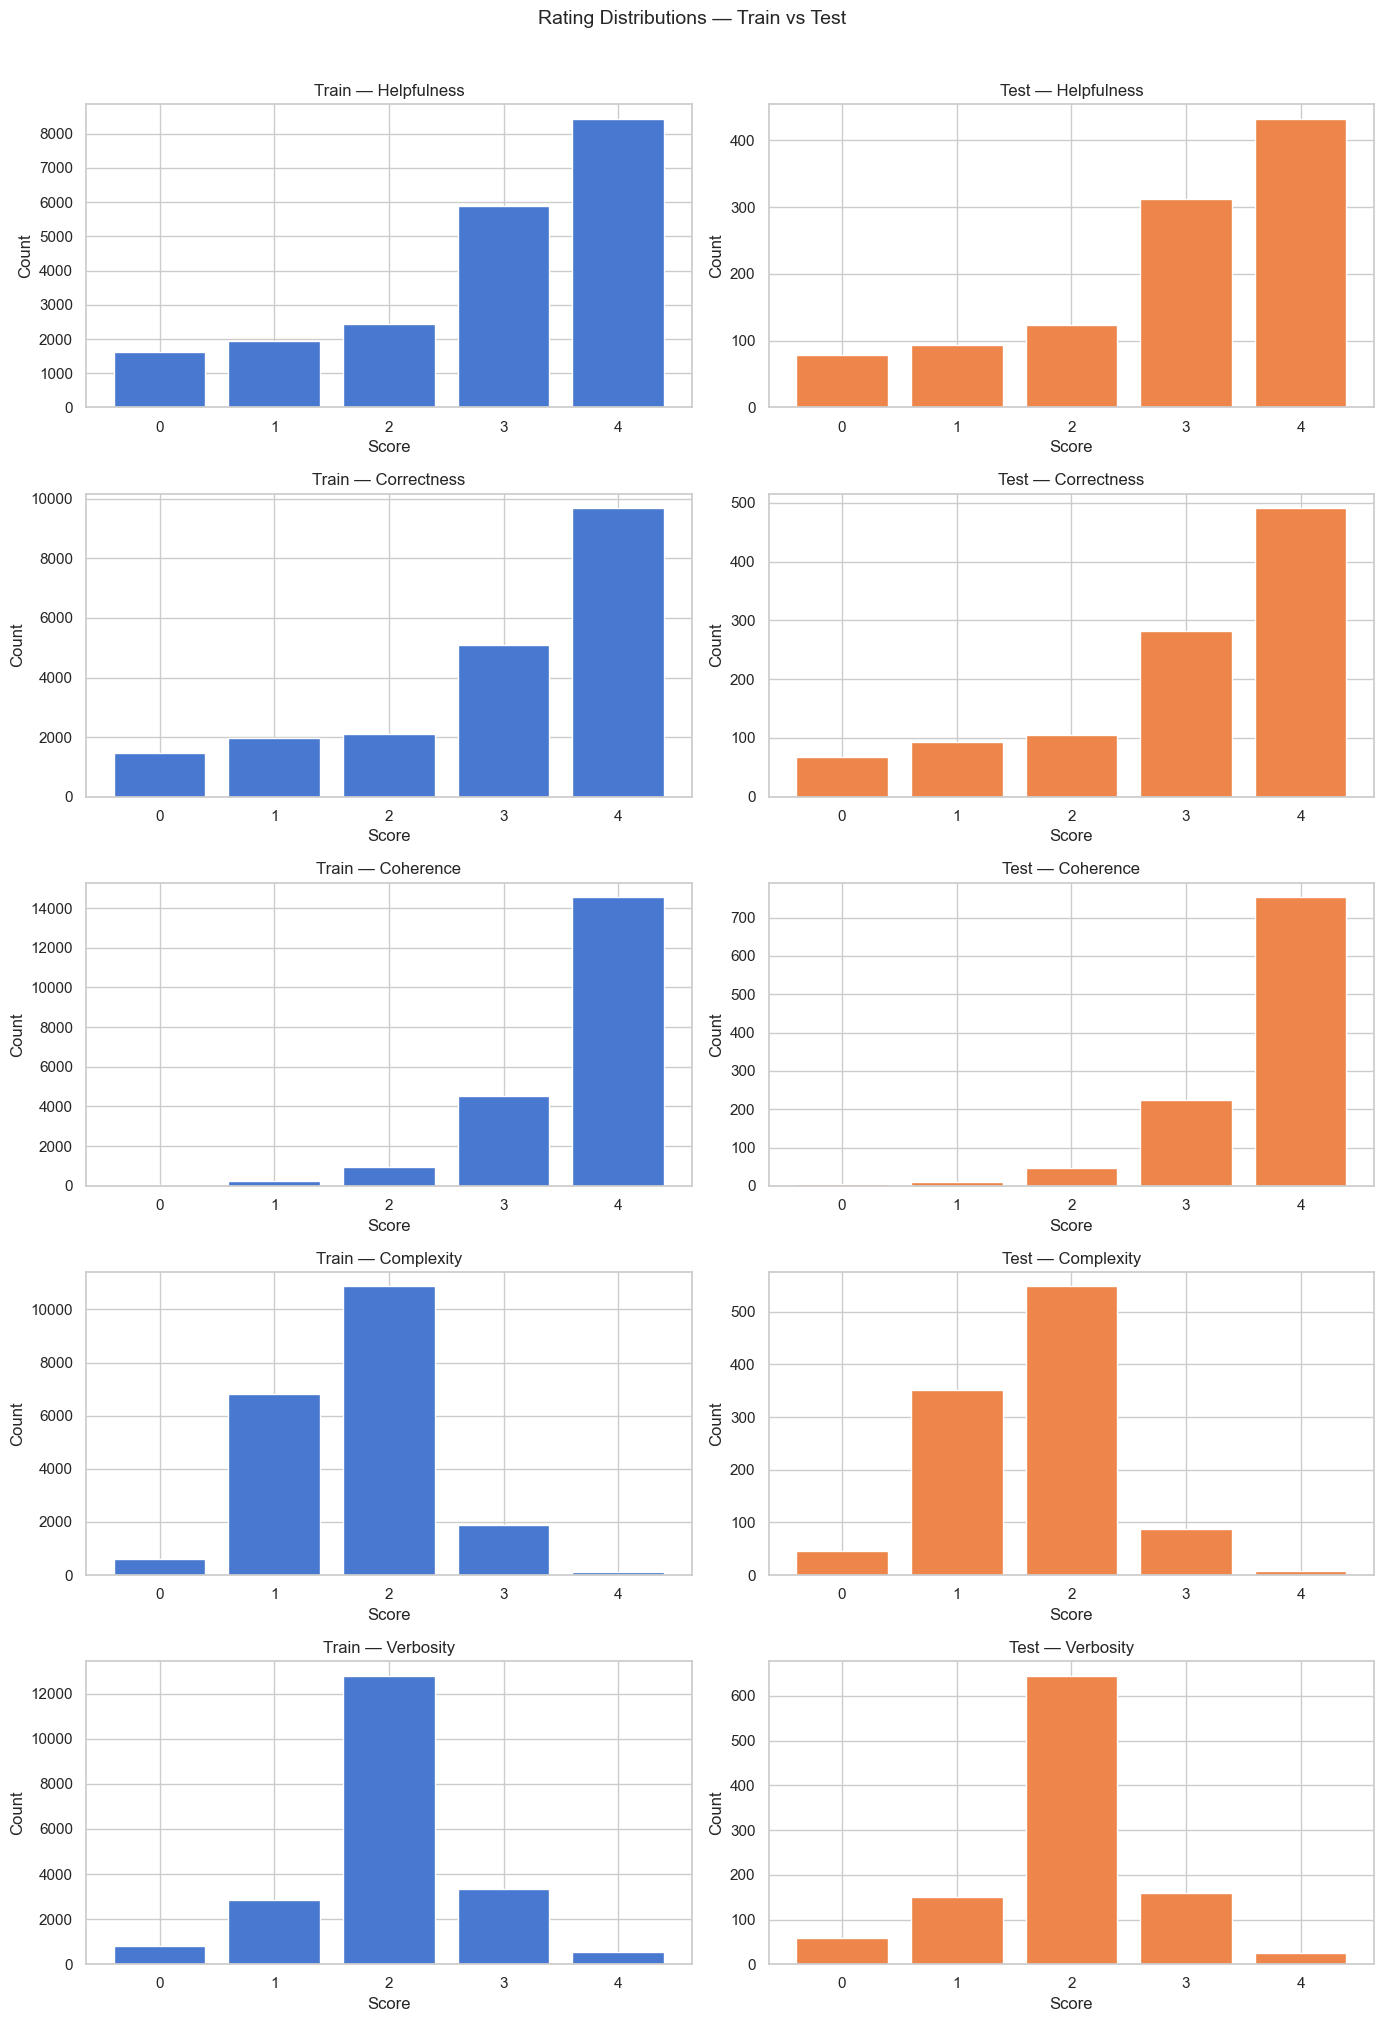

In [37]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, col in enumerate(RATING_COLS):
    scores = sorted(set(df_train[col].unique()) | set(df_test[col].unique()))

    train_counts = df_train[col].value_counts().reindex(scores, fill_value=0)
    axes[i, 0].bar(scores, train_counts, edgecolor="white", color=sns.color_palette("muted")[0])
    axes[i, 0].set_title(f"Train — {col.capitalize()}")
    axes[i, 0].set_xlabel("Score")
    axes[i, 0].set_ylabel("Count")

    test_counts = df_test[col].value_counts().reindex(scores, fill_value=0)
    axes[i, 1].bar(scores, test_counts, edgecolor="white", color=sns.color_palette("muted")[1])
    axes[i, 1].set_title(f"Test — {col.capitalize()}")
    axes[i, 1].set_xlabel("Score")
    axes[i, 1].set_ylabel("Count")

fig.suptitle("Rating Distributions — Train vs Test", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/rating_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Correlation Between Metrics

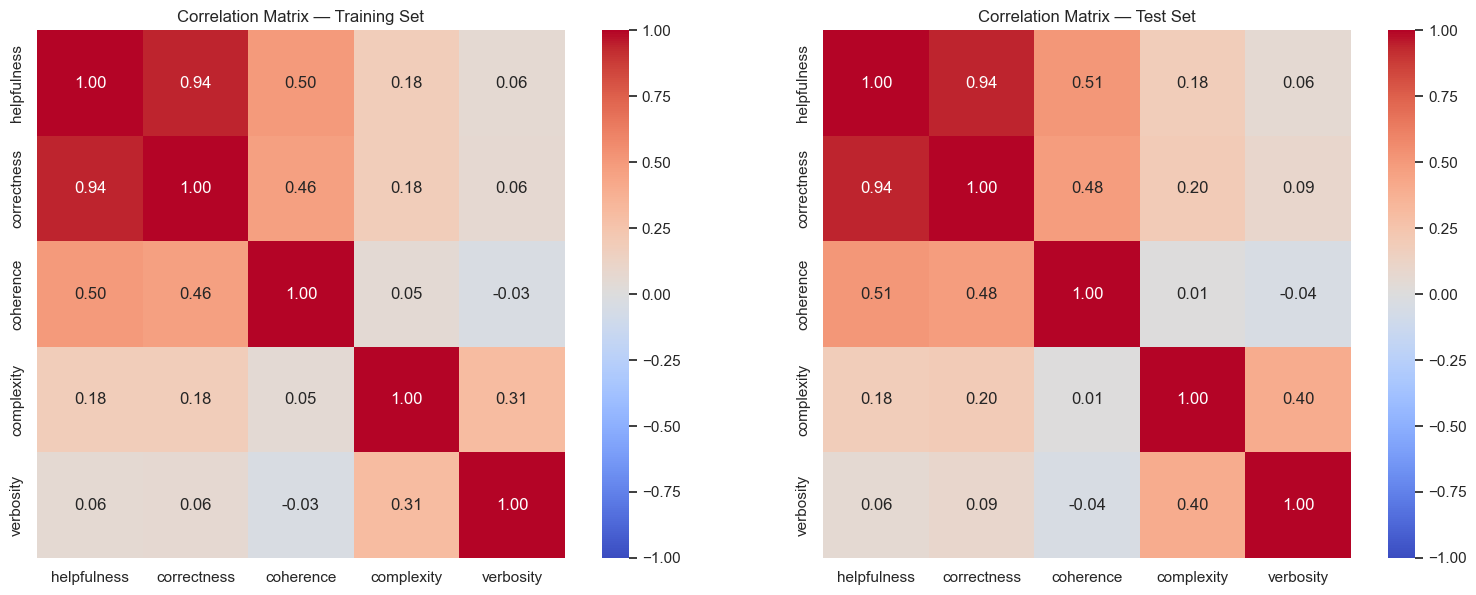

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes, [df_train, df_test], ["Training Set", "Test Set"]):
    corr = data[RATING_COLS].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"Correlation Matrix — {title}")

plt.tight_layout()
plt.savefig("figures/metric_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Text Length Analysis

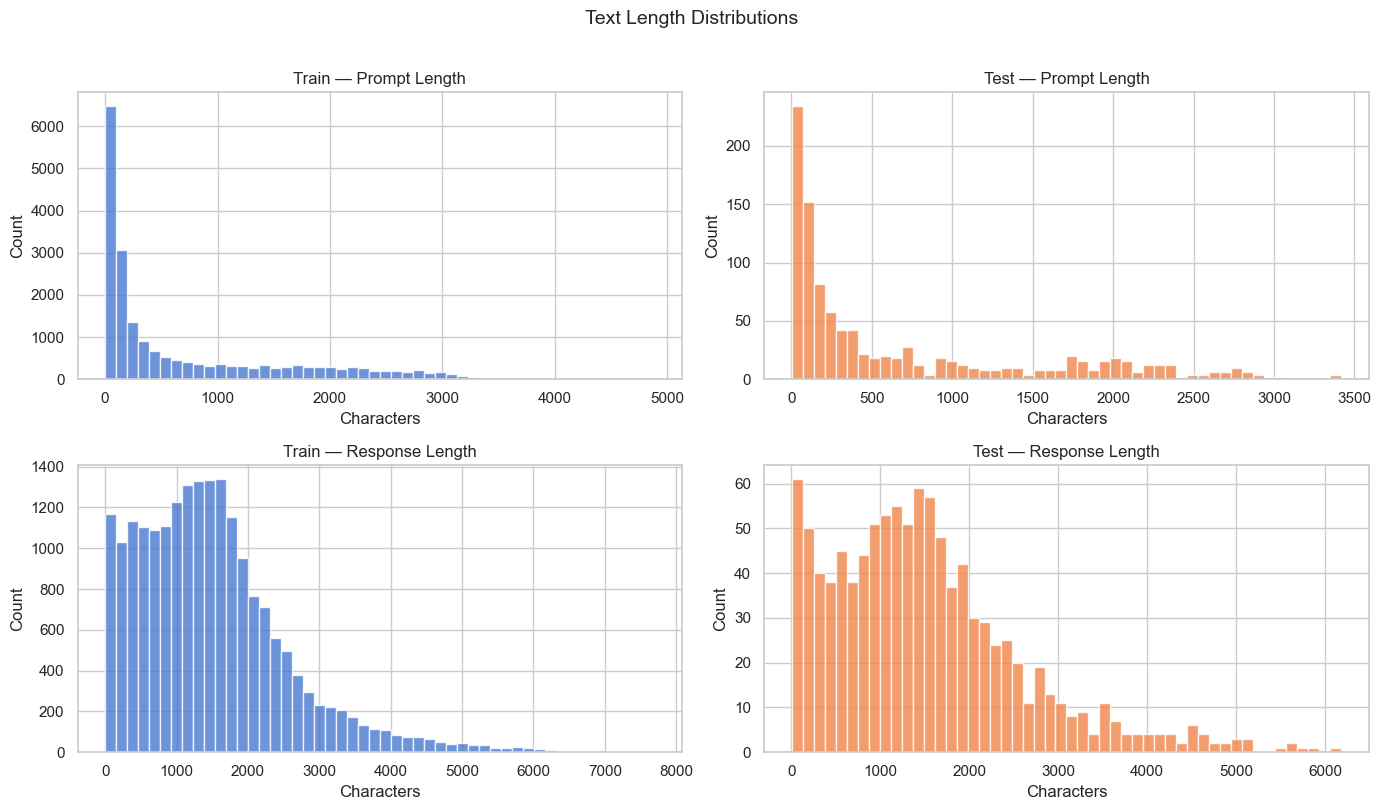

Train — prompt: mean 714, median 238 | response: mean 1492, median 1342
Test — prompt: mean 693, median 267 | response: mean 1503, median 1356


In [39]:
for d in [df_train, df_test]:
    d["prompt_len"] = d["prompt"].str.len()
    d["response_len"] = d["response"].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df_train["prompt_len"], bins=50, alpha=0.8, edgecolor="white", color=sns.color_palette("muted")[0])
axes[0, 0].set_title("Train — Prompt Length")

axes[0, 1].hist(df_test["prompt_len"], bins=50, alpha=0.8, edgecolor="white", color=sns.color_palette("muted")[1])
axes[0, 1].set_title("Test — Prompt Length")

axes[1, 0].hist(df_train["response_len"], bins=50, alpha=0.8, edgecolor="white", color=sns.color_palette("muted")[0])
axes[1, 0].set_title("Train — Response Length")

axes[1, 1].hist(df_test["response_len"], bins=50, alpha=0.8, edgecolor="white", color=sns.color_palette("muted")[1])
axes[1, 1].set_title("Test — Response Length")

for ax in axes.flat:
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")

fig.suptitle("Text Length Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/text_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

for name, d in [("Train", df_train), ("Test", df_test)]:
    print(f"{name} — prompt: mean {d['prompt_len'].mean():.0f}, median {d['prompt_len'].median():.0f} | "
          f"response: mean {d['response_len'].mean():.0f}, median {d['response_len'].median():.0f}")

## 5. Response Length vs. Ratings

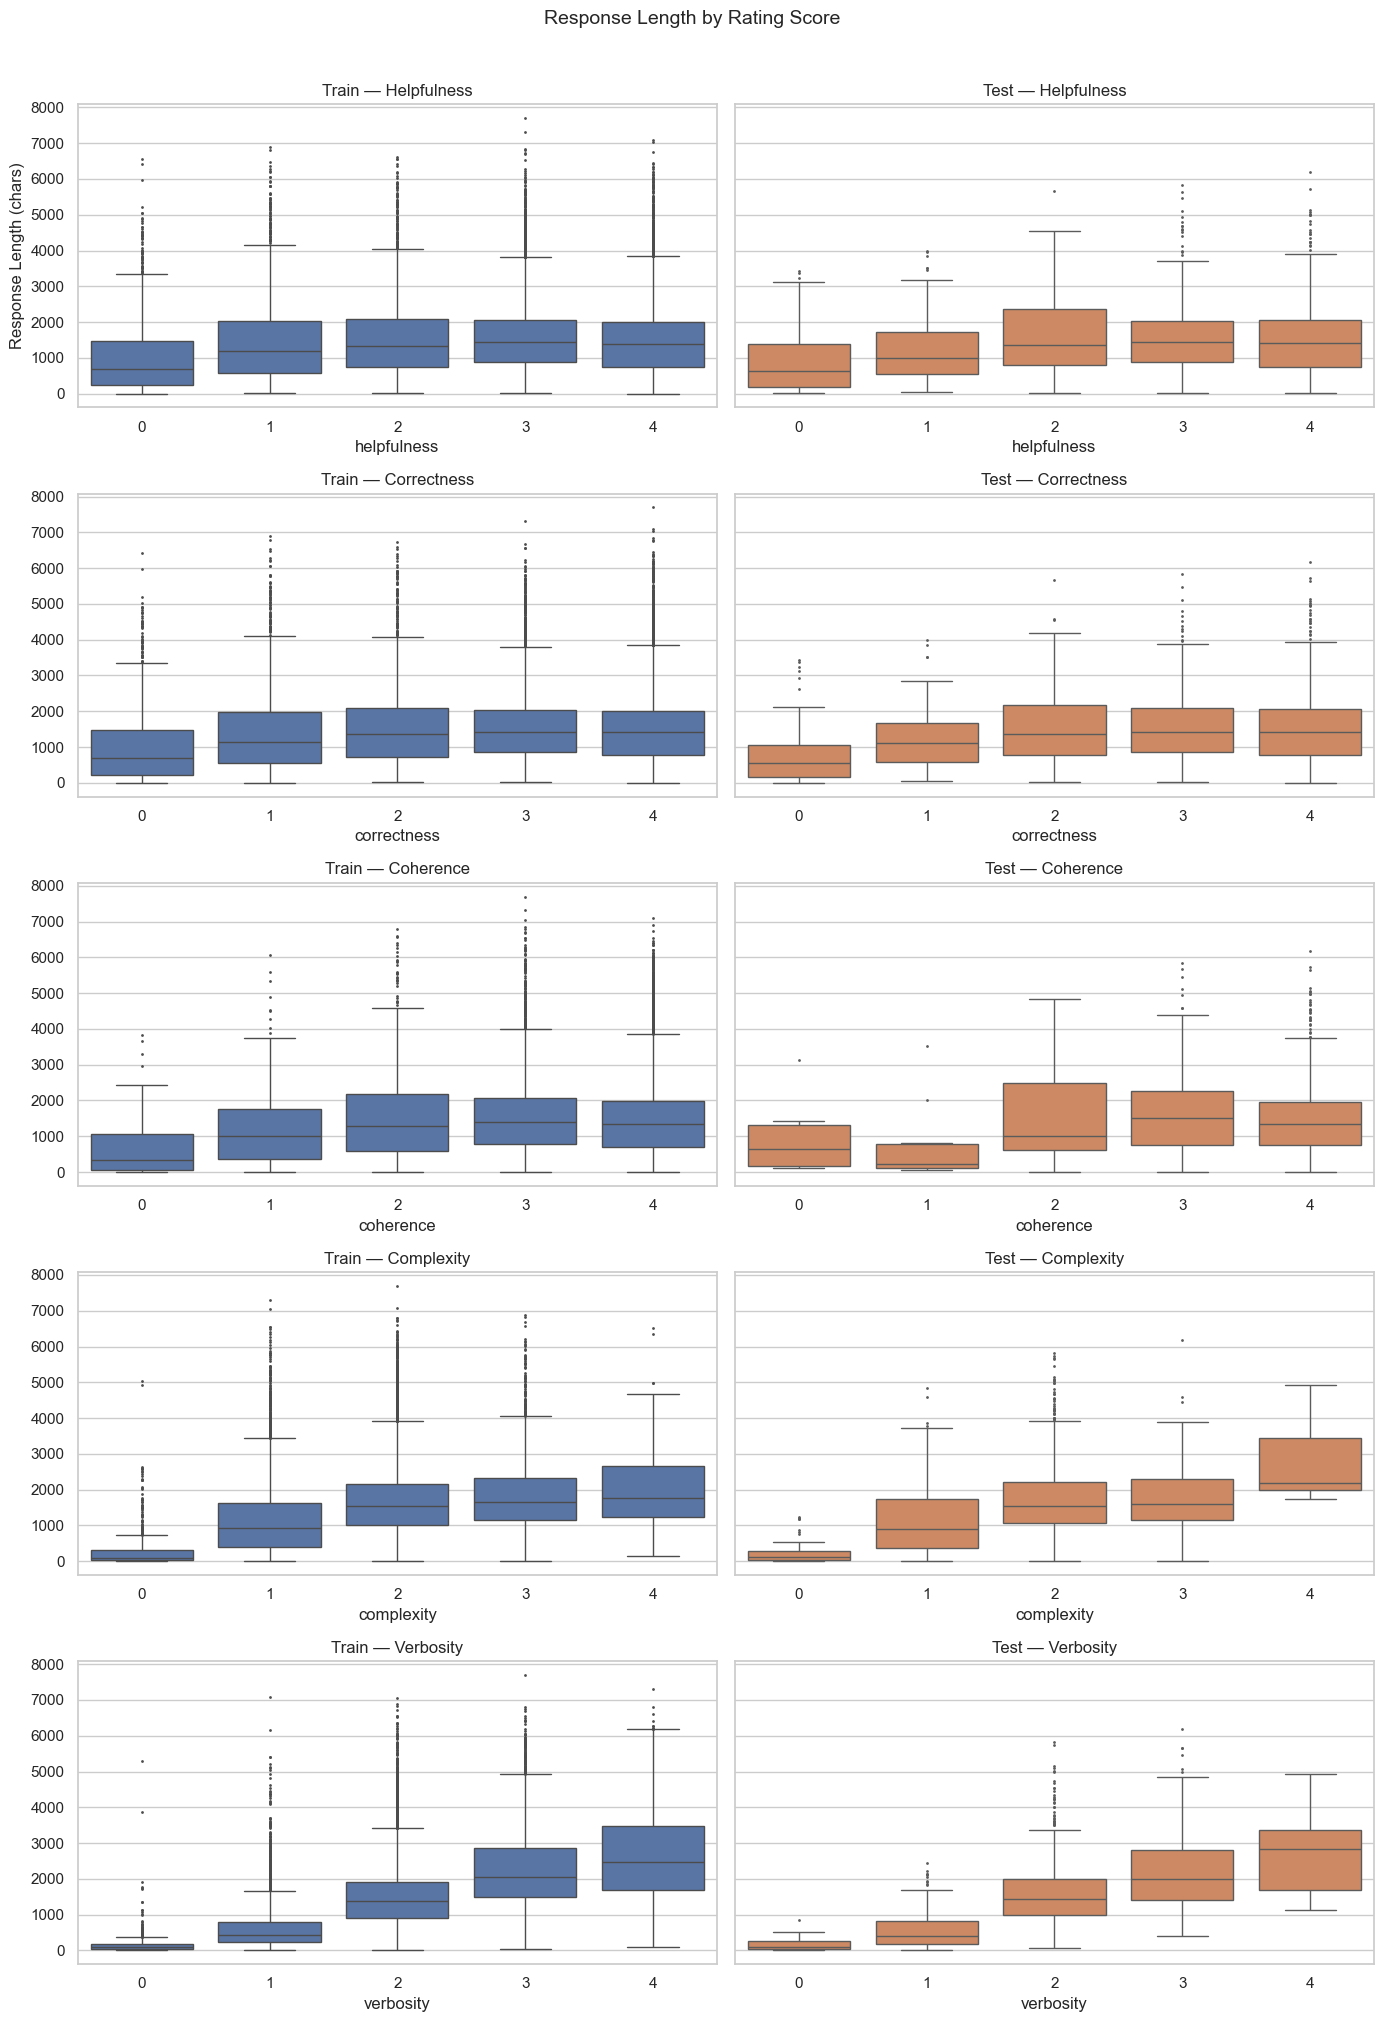

In [40]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharey=True)

for i, col in enumerate(RATING_COLS):
    sns.boxplot(data=df_train, x=col, y="response_len", ax=axes[i, 0], fliersize=1, color="#4C72B0")
    axes[i, 0].set_title(f"Train — {col.capitalize()}")
    axes[i, 0].set_ylabel("Response Length (chars)" if i == 0 else "")

    sns.boxplot(data=df_test, x=col, y="response_len", ax=axes[i, 1], fliersize=1, color="#DD8452")
    axes[i, 1].set_title(f"Test — {col.capitalize()}")
    axes[i, 1].set_ylabel("")

fig.suptitle("Response Length by Rating Score", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/response_length_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Responses per Prompt

In [41]:
for name, d in [("Train", df_train), ("Test", df_test)]:
    rpp = d.groupby("prompt").size()
    print(f"{name} — responses per prompt: mean {rpp.mean():.1f}, min {rpp.min()}, max {rpp.max()}")
    print(f"  Distribution: {rpp.value_counts().sort_index().to_dict()}\n")

Train — responses per prompt: mean 2.0, min 2, max 4
  Distribution: {2: 10160, 4: 1}

Test — responses per prompt: mean 2.0, min 2, max 2
  Distribution: {2: 519}



## 7. Helpfulness Gap Between Best and Worst Response per Prompt

--- Gap Statistics Across All Metrics ---
[Train | Helpfulness] Gap == 0: 2941 | Gap >= 2: 3633
[Test | Helpfulness] Gap == 0: 146 | Gap >= 2: 182
[Train | Correctness] Gap == 0: 3367 | Gap >= 2: 3361
[Test | Correctness] Gap == 0: 165 | Gap >= 2: 170
[Train | Coherence] Gap == 0: 5957 | Gap >= 2: 833
[Test | Coherence] Gap == 0: 323 | Gap >= 2: 44
[Train | Complexity] Gap == 0: 7496 | Gap >= 2: 237
[Test | Complexity] Gap == 0: 376 | Gap >= 2: 16
[Train | Verbosity] Gap == 0: 5081 | Gap >= 2: 1497
[Test | Verbosity] Gap == 0: 265 | Gap >= 2: 83


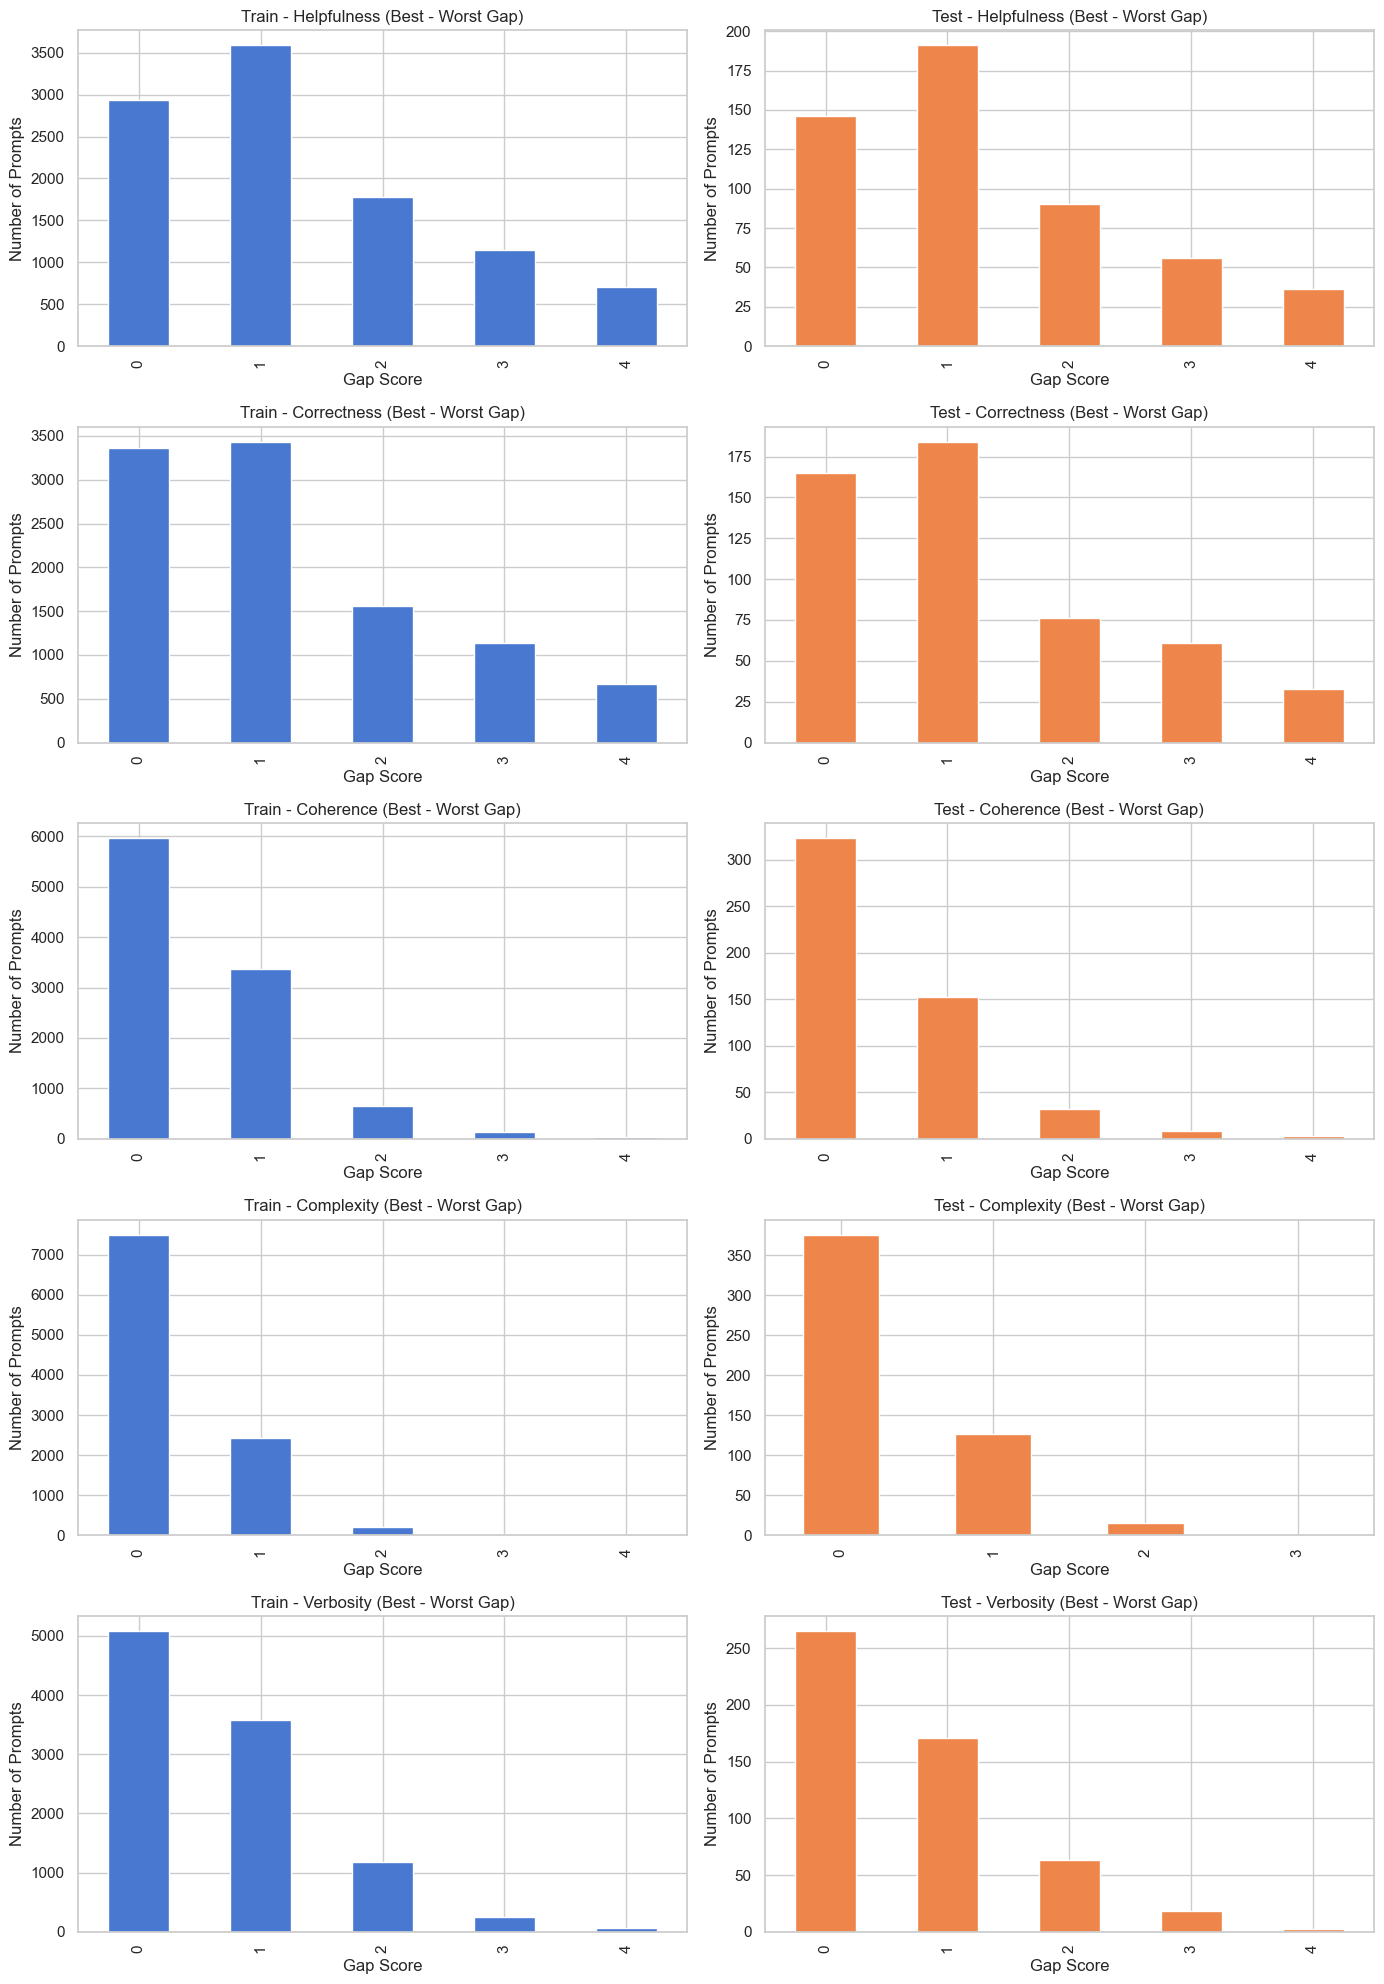

In [42]:
metrics = ["helpfulness", "correctness", "coherence", "complexity", "verbosity"]

def plot_metric_gap(df, ax, title, metric_name, color_idx):
    gap_df = df.groupby("prompt")[metric_name].agg(best="max", worst="min")
    gap_df["gap"] = gap_df["best"] - gap_df["worst"]
    
    counts = gap_df["gap"].value_counts().sort_index()
    counts.plot.bar(edgecolor="white", color=sns.color_palette("muted")[color_idx], ax=ax)
    
    ax.set_title(f"{title} - {metric_name.capitalize()} (Best - Worst Gap)")
    ax.set_xlabel("Gap Score")
    ax.set_ylabel("Number of Prompts")
    
    gap_0 = (gap_df['gap'] == 0).sum()
    gap_2_plus = (gap_df['gap'] >= 2).sum()
    print(f"[{title} | {metric_name.capitalize()}] Gap == 0: {gap_0} | Gap >= 2: {gap_2_plus}")

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

print("--- Gap Statistics Across All Metrics ---")

for i, metric in enumerate(metrics):

    plot_metric_gap(df_train, axes[i, 0], "Train", metric, color_idx=0)
    
    plot_metric_gap(df_test, axes[i, 1], "Test", metric, color_idx=1)

plt.tight_layout()
plt.savefig("figures/metric_gap_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

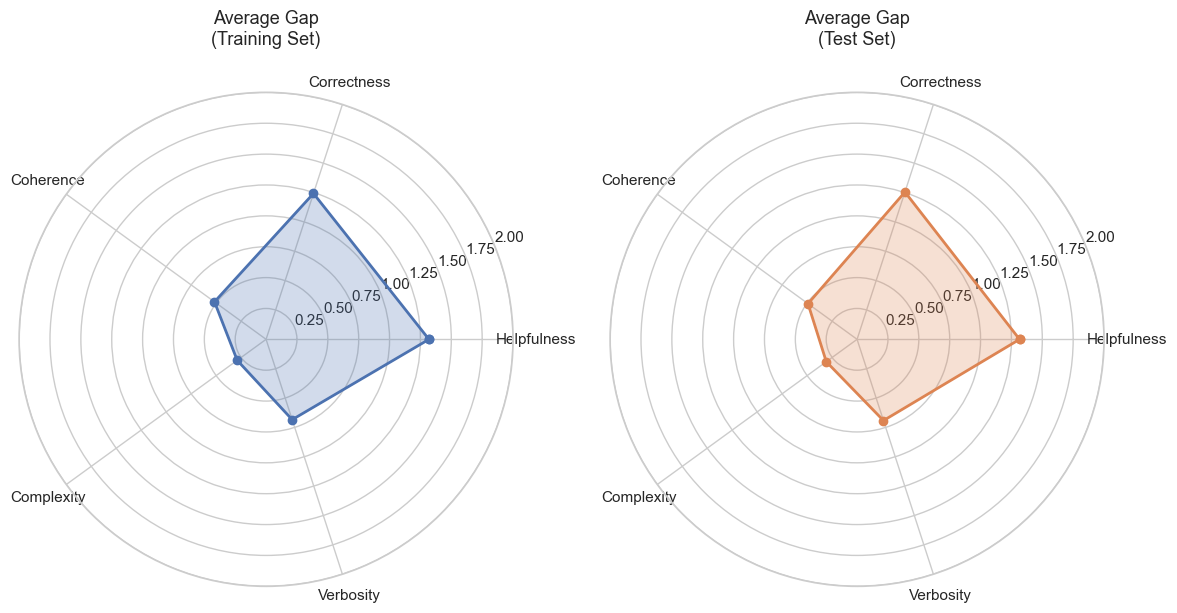

In [43]:
def get_avg_gaps(df, metrics_list):
    avg_gaps = []
    for m in metrics_list:
        gap_df = df.groupby("prompt")[m].agg(best="max", worst="min")
        gap_df["gap"] = gap_df["best"] - gap_df["worst"]
        avg_gaps.append(gap_df["gap"].mean())
    return avg_gaps

avg_gaps_train = get_avg_gaps(df_train, metrics)
avg_gaps_test = get_avg_gaps(df_test, metrics)

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  

values_train = avg_gaps_train + avg_gaps_train[:1]
values_test = avg_gaps_test + avg_gaps_test[:1]

max_val = max(max(values_train), max(values_test))
y_max = np.ceil(max_val * 1.2) 

fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(polar=True))

axes[0].fill(angles, values_train, alpha=0.25, color="#4C72B0") 
axes[0].plot(angles, values_train, "o-", linewidth=2, color="#4C72B0")
axes[0].set_thetagrids(np.degrees(angles[:-1]), [m.capitalize() for m in metrics])
axes[0].set_ylim(0, y_max)
axes[0].set_title("Average Gap\n(Training Set)", y=1.08, fontsize=13)

axes[1].fill(angles, values_test, alpha=0.25, color="#DD8452")
axes[1].plot(angles, values_test, "o-", linewidth=2, color="#DD8452")
axes[1].set_thetagrids(np.degrees(angles[:-1]), [m.capitalize() for m in metrics])
axes[1].set_ylim(0, y_max)
axes[1].set_title("Average Gap\n(Test Set)", y=1.08, fontsize=13)

plt.tight_layout()
plt.savefig("figures/average_gap_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Average Ratings Overview (Radar Chart)

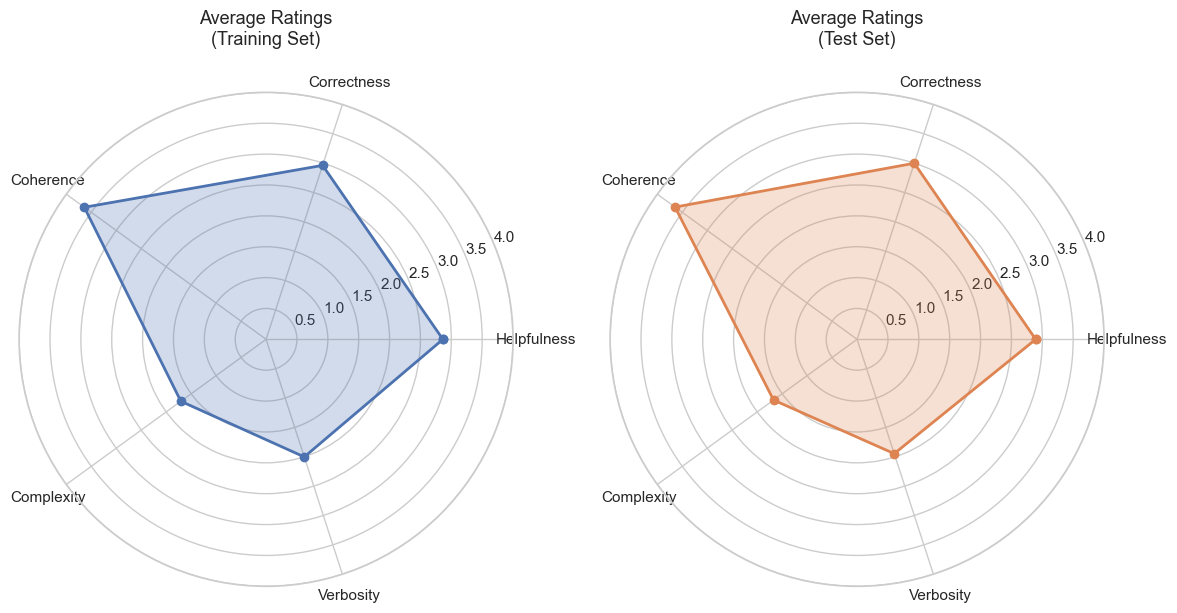

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(polar=True))

means_train = df_train[RATING_COLS].mean().tolist()
values_train = means_train + means_train[:1]  

axes[0].fill(angles, values_train, alpha=0.25, color="#4C72B0") 
axes[0].plot(angles, values_train, "o-", linewidth=2, color="#4C72B0")
axes[0].set_thetagrids(np.degrees(angles[:-1]), [c.capitalize() for c in RATING_COLS])
axes[0].set_ylim(0, 4)
axes[0].set_title("Average Ratings\n(Training Set)", y=1.08, fontsize=13)

means_test = df_test[RATING_COLS].mean().tolist()
values_test = means_test + means_test[:1]  

axes[1].fill(angles, values_test, alpha=0.25, color="#DD8452") 
axes[1].plot(angles, values_test, "o-", linewidth=2, color="#DD8452")
axes[1].set_thetagrids(np.degrees(angles[:-1]), [c.capitalize() for c in RATING_COLS])
axes[1].set_ylim(0, 4)
axes[1].set_title("Average Ratings\n(Test Set)", y=1.08, fontsize=13)

plt.tight_layout()
plt.savefig("figures/average_ratings_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Pair Construction — Simulating `_load_helpsteer2`

The pipeline builds preference pairs by grouping responses by prompt, scoring each response as the mean of *helpfulness*, *correctness*, and *coherence*, and then pairing the **best** vs **worst** response per prompt.

Below we replicate that logic on the raw dataframe and analyse the resulting pairs.

In [45]:
pairs_train = pd.read_csv("../data/helpsteer2_train_full.csv")
pairs_test = pd.read_csv("../data/helpsteer2_validation_full.csv")

print(f"Pairs loaded — Train: {len(pairs_train)}, Test: {len(pairs_test)}")
pairs_train.head()

Pairs loaded — Train: 10166, Test: 519


,prompt_id,prompt,response_a,response_b,gold_label,helpfulness_a,correctness_a,coherence_a,complexity_a,verbosity_a,...,helpfulness_b,correctness_b,coherence_b,complexity_b,verbosity_b,score_b,score_gap,len_a,len_b,difficulty
0,240aa2cec4,c#,"C# (pronounced ""C sharp"") is a modern, object-...","C# is a high-level, object-oriented programmin...",A,4,4,4,2,3,...,3,4,4,2,1,3.6667,0.3333,1634,691,medium
1,823aad83e7,bacillus subtilus,"Bacillus subtilis is a Gram-positive, rod-shap...","The Bacillus subtilis is a Gram-positive, endo...",A,4,4,4,3,3,...,3,4,3,3,2,3.3333,0.6667,1408,1118,medium
2,598ee4176c,Write long detailed essay about ancient type o...,Totemism is an ancient type of religion that i...,Totemism is an ancient religious and philosoph...,C,3,3,3,2,2,...,3,3,3,2,3,3.0000,0.0000,2215,3631,hard
3,41e9118a2e,Define Signal Discuss its various properties w...,A signal is a message that is conveyed from a ...,A signal is a form of energy that is used to t...,A,3,4,3,1,2,...,3,3,3,1,2,3.0000,0.3333,1971,927,medium
4,cc8b90e58c,how do you prepare potatos for frying,Here are some steps to prepare potatoes for fr...,"To prepare potatoes for frying, you can follow...",A,3,4,4,2,2,...,3,3,4,2,2,3.3333,0.3333,1124,1373,medium


### 9.1 Gold Label Distribution

How often is there a clear winner (A), and how many prompts end up as ties (C)?

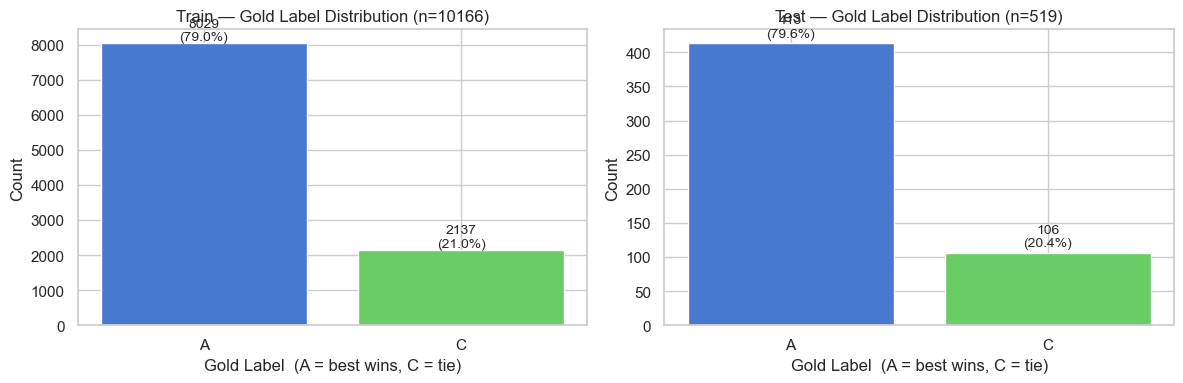

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(axes, [pairs_train, pairs_test], ["Train", "Test"]):
    counts = data["gold_label"].value_counts().reindex(["A", "C"], fill_value=0)
    bars = ax.bar(counts.index, counts.values, edgecolor="white",
                  color=[sns.color_palette("muted")[0],
                         sns.color_palette("muted")[2]])
    ax.set_title(f"{title} — Gold Label Distribution (n={len(data)})")
    ax.set_xlabel("Gold Label  (A = best wins, C = tie)")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 5,
                f"{v}\n({v/len(data)*100:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("figures/gold_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2 Score Gap Distribution

The score gap measures how much better the best response is compared to the worst for each prompt. Larger gaps mean easier judgements for the LLM judge.

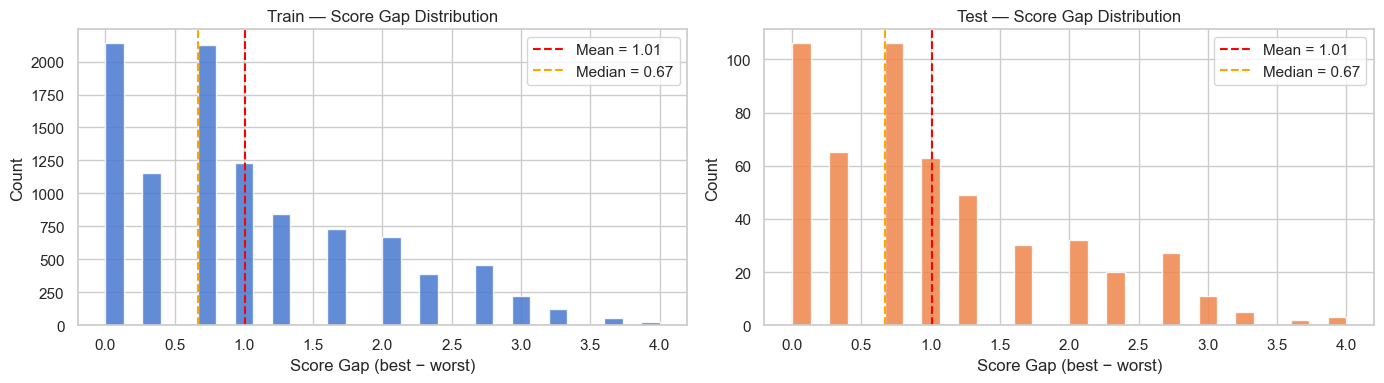

Train — score_gap: mean=1.005, median=0.667, std=0.893, zero-gap (ties)=2137 (21.0%)
Test — score_gap: mean=1.006, median=0.667, std=0.901, zero-gap (ties)=106 (20.4%)


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title, color in zip(axes, [pairs_train, pairs_test],
                                    ["Train", "Test"],
                                    [sns.color_palette("muted")[0], sns.color_palette("muted")[1]]):
    ax.hist(data["score_gap"], bins=30, edgecolor="white", color=color, alpha=0.85)
    ax.axvline(data["score_gap"].mean(), color="red", ls="--", label=f'Mean = {data["score_gap"].mean():.2f}')
    ax.axvline(data["score_gap"].median(), color="orange", ls="--", label=f'Median = {data["score_gap"].median():.2f}')
    ax.set_title(f"{title} — Score Gap Distribution")
    ax.set_xlabel("Score Gap (best − worst)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/score_gap_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

for name, data in [("Train", pairs_train), ("Test", pairs_test)]:
    print(f"{name} — score_gap: mean={data['score_gap'].mean():.3f}, "
          f"median={data['score_gap'].median():.3f}, "
          f"std={data['score_gap'].std():.3f}, "
          f"zero-gap (ties)={( data['score_gap'] == 0).sum()} "
          f"({(data['score_gap'] == 0).mean()*100:.1f}%)")

### 9.3 Best vs Worst Score Distributions

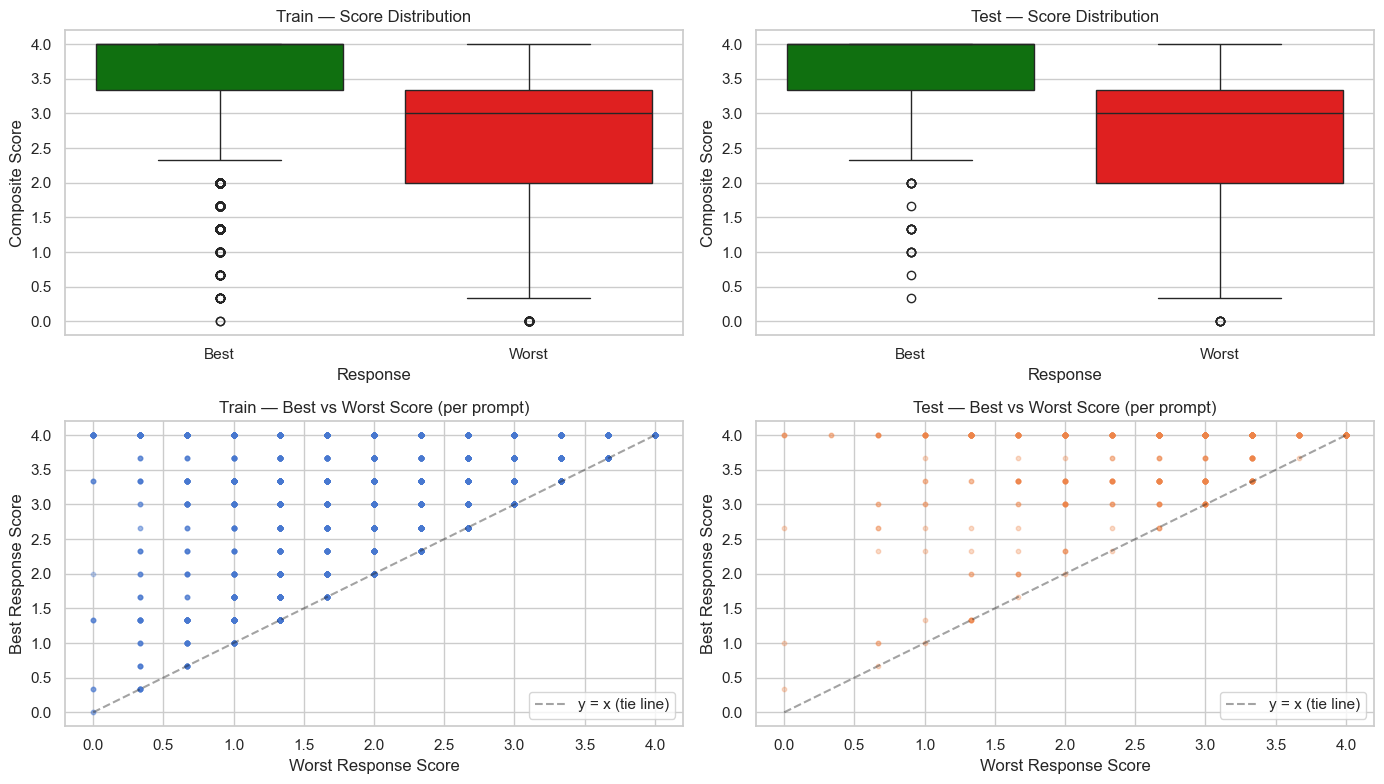

Train — Best score: mean=3.66, Worst score: mean=2.65
Test — Best score: mean=3.68, Worst score: mean=2.68


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (data, title) in enumerate([(pairs_train, "Train"), (pairs_test, "Test")]):
    # Top row: side-by-side boxplots
    melted = pd.DataFrame({
        "Best": data["score_a"],
        "Worst": data["score_b"]
    }).melt(var_name="Response", value_name="Score")
    sns.boxplot(data=melted, x="Response", y="Score", hue="Response", ax=axes[0, col],
                palette={"Best": "green", "Worst": "red"}, legend=False)
    axes[0, col].set_title(f"{title} — Score Distribution")
    axes[0, col].set_ylabel("Composite Score")

    # Bottom row: scatter best vs worst
    ax = axes[1, col]
    ax.scatter(data["score_b"], data["score_a"], alpha=0.3, s=10, color=sns.color_palette("muted")[col])
    ax.plot([0, 4], [0, 4], "k--", alpha=0.4, label="y = x (tie line)")
    ax.set_xlabel("Worst Response Score")
    ax.set_ylabel("Best Response Score")
    ax.set_title(f"{title} — Best vs Worst Score (per prompt)")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/best_vs_worst_score.png", dpi=150, bbox_inches="tight")
plt.show()

for name, data in [("Train", pairs_train), ("Test", pairs_test)]:
    print(f"{name} — Best score: mean={data['score_a'].mean():.2f}, "
          f"Worst score: mean={data['score_b'].mean():.2f}")

### 9.4 Response Length Comparison — Best vs Worst

Does the "better" response tend to be longer? This is relevant because LLM judges are known to exhibit a verbosity bias.

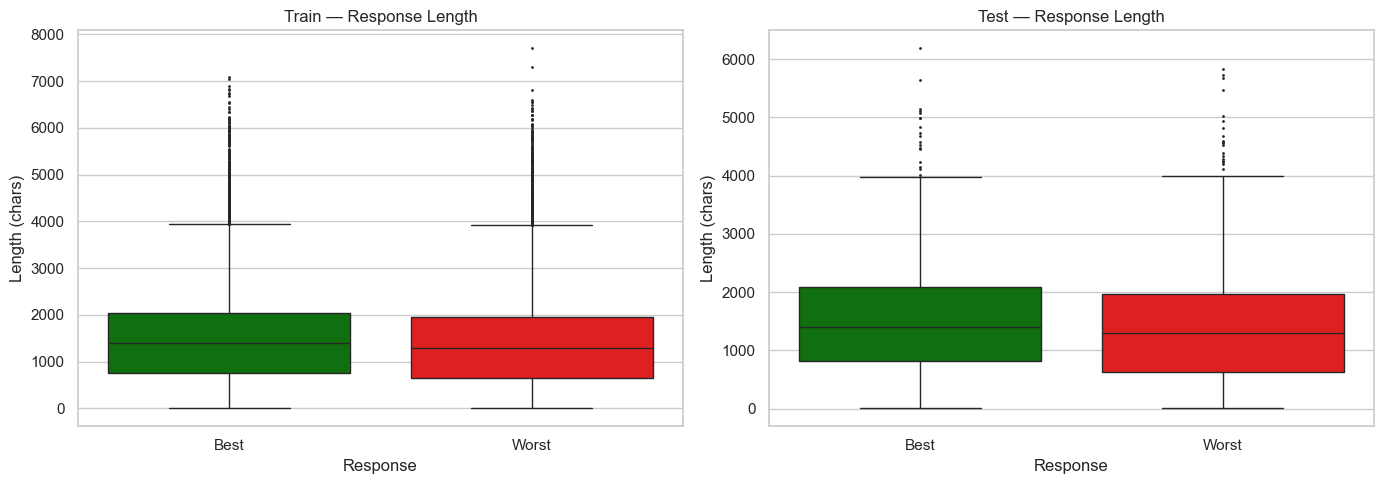

Train — Best response is longer in 54.0% of pairs | Mean best len: 1530, Mean worst len: 1453
Test — Best response is longer in 56.5% of pairs | Mean best len: 1553, Mean worst len: 1453


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [pairs_train, pairs_test], ["Train", "Test"]):
    melted_len = pd.DataFrame({
        "Best": data["len_a"],
        "Worst": data["len_b"]
    }).melt(var_name="Response", value_name="Length (chars)")
    sns.boxplot(data=melted_len, x="Response", y="Length (chars)", hue="Response",
                ax=ax, palette={"Best": "green", "Worst": "red"}, legend=False,
                fliersize=1)
    ax.set_title(f"{title} — Response Length")

plt.tight_layout()
plt.savefig("figures/response_length_best_vs_worst.png", dpi=150, bbox_inches="tight")
plt.show()

for name, data in [("Train", pairs_train), ("Test", pairs_test)]:
    best_longer = (data["len_a"] > data["len_b"]).mean() * 100
    print(f"{name} — Best response is longer in {best_longer:.1f}% of pairs | "
          f"Mean best len: {data['len_a'].mean():.0f}, "
          f"Mean worst len: {data['len_b'].mean():.0f}")

### 9.5 Score Gap vs Response Length Difference

Is the score gap correlated with the length difference between best and worst responses?

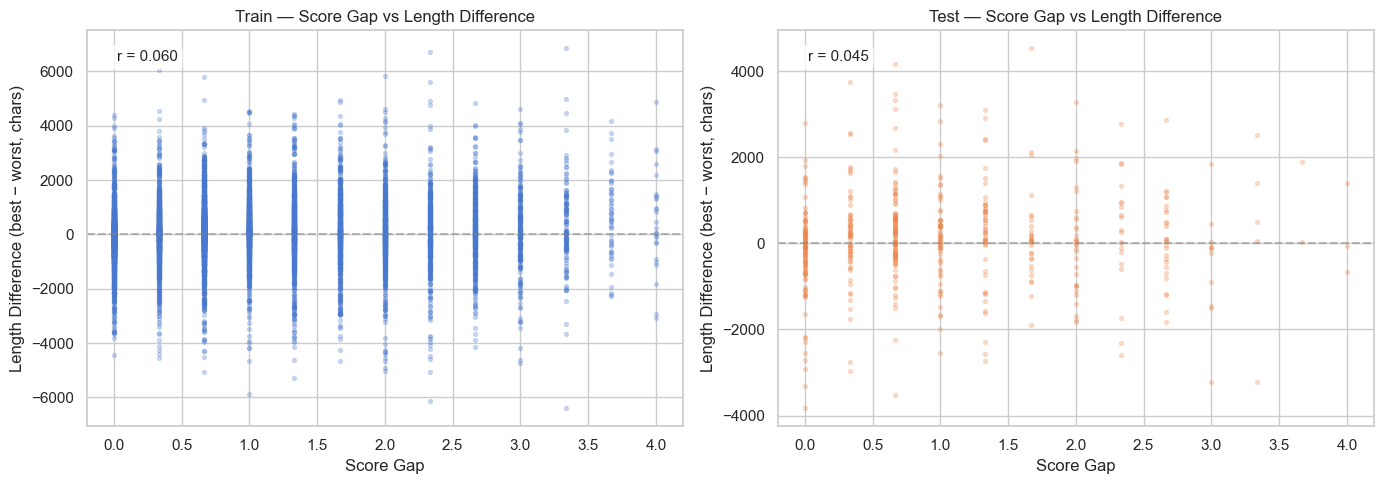

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(axes, [pairs_train, pairs_test],
                                    ["Train", "Test"],
                                    [sns.color_palette("muted")[0], sns.color_palette("muted")[1]]):
    len_diff = data["len_a"] - data["len_b"]
    ax.scatter(data["score_gap"], len_diff, alpha=0.25, s=8, color=color)
    ax.set_xlabel("Score Gap")
    ax.set_ylabel("Length Difference (best − worst, chars)")
    ax.set_title(f"{title} — Score Gap vs Length Difference")
    ax.axhline(0, color="gray", ls="--", alpha=0.5)

    corr = data["score_gap"].corr(len_diff)
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes,
            fontsize=11, va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
plt.savefig("figures/score_gap_vs_length_diff.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.6 Difficulty Buckets — Easy, Medium, Hard

We categorise pairs by score gap into difficulty tiers:
- **Easy**: gap ≥ 1.0  
- **Medium**: 0 < gap < 1.0  
- **Hard**: gap = 0 (tie)

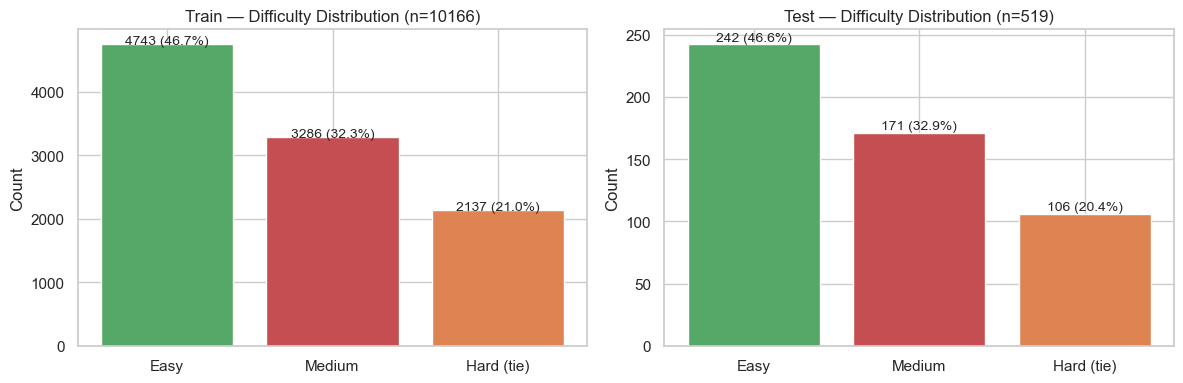

In [51]:
def difficulty_bucket(gap):
    if gap == 0:
        return "Hard (tie)"
    elif gap < 1.0:
        return "Medium"
    else:
        return "Easy"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(axes, [pairs_train, pairs_test], ["Train", "Test"]):
    data = data.copy()
    data["difficulty"] = data["score_gap"].apply(difficulty_bucket)
    counts = data["difficulty"].value_counts().reindex(["Easy", "Medium", "Hard (tie)"], fill_value=0)
    bars = ax.bar(counts.index, counts.values, edgecolor="white",
                  color=["#55a868", "#c44e52", "#dd8452"])
    ax.set_title(f"{title} — Difficulty Distribution (n={len(data)})")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 3,
                f"{v} ({v/len(data)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/difficulty_buckets.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.7 Summary Statistics

In [52]:
for name, data in [("Train", pairs_train), ("Test", pairs_test)]:
    print(f"=== {name} Set ({len(data)} pairs) ===")
    print(f"  Label distribution: {data['gold_label'].value_counts().to_dict()}")
    print(f"  Score gap — mean: {data['score_gap'].mean():.3f}, "
          f"median: {data['score_gap'].median():.3f}, "
          f"std: {data['score_gap'].std():.3f}")
    print(f"  Ties (gap=0): {(data['score_gap']==0).sum()} ({(data['score_gap']==0).mean()*100:.1f}%)")
    best_longer = (data["len_a"] > data["len_b"]).mean() * 100
    print(f"  Best response longer: {best_longer:.1f}%")
    len_diff = data["len_a"] - data["len_b"]
    print(f"  Correlation(score_gap, len_diff): {data['score_gap'].corr(len_diff):.3f}")
    print()

=== Train Set (10166 pairs) ===
  Label distribution: {'A': 8029, 'C': 2137}
  Score gap — mean: 1.005, median: 0.667, std: 0.893
  Ties (gap=0): 2137 (21.0%)
  Best response longer: 54.0%
  Correlation(score_gap, len_diff): 0.060

=== Test Set (519 pairs) ===
  Label distribution: {'A': 413, 'C': 106}
  Score gap — mean: 1.006, median: 0.667, std: 0.901
  Ties (gap=0): 106 (20.4%)
  Best response longer: 56.5%
  Correlation(score_gap, len_diff): 0.045

